In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import json

# Data Exploration

In [12]:
df = pd.read_csv("../../data/Complete_Updated_Autoimmune_Disorder_Dataset2.csv")
df = pd.DataFrame(df)
pd.set_option('display.max_columns', None)

In [13]:
df.shape

(13812, 79)

In [14]:
df.head()

,Patient_ID,Age,Gender,Diagnosis,Sickness_Duration_Months,RBC_Count,Hemoglobin,Hematocrit,MCV,MCH,MCHC,RDW,Reticulocyte_Count,WBC_Count,Neutrophils,Lymphocytes,Monocytes,Eosinophils,Basophils,PLT_Count,MPV,ANA,Esbach,MBL_Level,ESR,C3,C4,CRP,Anti-dsDNA,Anti-Sm,Rheumatoid factor,ACPA,Anti-TPO,Anti-Tg,Anti-SMA,Low-grade fever,Fatigue or chronic tiredness,Dizziness,Weight loss,Rashes and skin lesions,Stiffness in the joints,Brittle hair or hair loss,Dry eyes and/or mouth,General 'unwell' feeling,Joint pain,Anti_dsDNA,Anti_enterocyte_antibodies,anti_LKM1,Anti_RNP,ASCA,Anti_Ro_SSA,Anti_CBir1,Anti_BP230,Anti_tTG,DGP,Anti_BP180,ASMA,Anti_IF,IgG_IgE_receptor,Anti_SRP,Anti_desmoglein_3,Anti_La_SSB,Anti_Jo1,ANCA,anti_centromere,Anti_desmoglein_1,EMA,Anti_type_VII_collagen,C1_inhibitor,Anti_TIF1,Anti_epidermal_basement_membrane_IgA,Anti_OmpC,pANCA,Anti_tissue_transglutaminase,anti_Scl_70,Anti_Mi2,Anti_parietal_cell,Progesterone_antibodies,Anti_Sm
0,6,62,Male,Autoimmune orchitis,41,4.75,13.37,43.11,101.91,28.41,34.98,12.12,2.77,4458.0,40.05,34.54,3.29,4.42,0.83,402793.0,8.45,1,154.915372,0.71,21.470329,14.274072,8.281658,29.182553,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0,1,0,0,1,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,20,54,Female,Autoimmune orchitis,41,4.32,10.76,39.92,95.96,28.22,31.70,12.89,2.98,4974.0,32.30,17.21,2.11,4.24,1.44,145389.0,7.22,0,447.570310,1.58,31.601330,2.083559,6.555046,22.356969,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1,0,1,0,1,1,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,46,34,Male,Autoimmune orchitis,86,4.42,11.91,38.38,80.56,28.40,35.21,12.73,1.35,8766.0,32.30,20.94,5.81,4.53,1.33,111764.0,11.63,0,236.292853,1.18,27.346259,73.459310,6.957688,24.933347,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1,0,0,1,1,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,108,22,Male,Autoimmune orchitis,43,4.33,12.72,39.99,84.71,26.67,31.25,14.62,1.63,8828.0,34.62,25.83,3.30,2.30,0.81,276336.0,8.40,1,239.695961,0.95,23.728429,67.439371,4.355488,46.448538,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0,1,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,142,20,Female,Autoimmune orchitis,50,3.99,11.07,43.58,89.87,30.64,32.77,14.45,2.12,4583.0,56.56,42.86,7.51,2.30,1.24,297272.0,9.73,0,466.374954,1.37,30.440890,54.250929,7.824894,45.904132,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0,1,1,1,1,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [15]:
if (df.isnull().sum() > 0).any():
    print("Valeurs nulles :")
    print(df.isnull().sum()[df.isnull().sum() > 0])
else:
    print("Aucune valeur nulle")

Aucune valeur nulle


# Data Cleaning

In [16]:
df.drop(columns=['Patient_ID'], inplace=True)

In [17]:
df['Gender']=df['Gender'].str.lower()

## Label Normalization

In [18]:
df['Diagnosis'].unique()

<ArrowStringArray>
[               'Autoimmune orchitis',               'Rheumatoid arthritis',
                   'Sjögren syndrome',                    'Graves' disease',
 'Systemic lupus erythematosus (SLE)',                             'Normal']
Length: 6, dtype: str

In [19]:
def diagnosis_naming(diagnosis):
            
    systemic_lupus_erythematosus = ['systemic lupus erythematosus (sle)'] 
                                
    sjogren_syndrome = ['sjögren syndrome']                   

    graves_disease = ["graves' disease"]

    rheumatoid_arthritis = ['rheumatoid arthritis']

    autoimmune_orchitis = ['autoimmune orchitis']

    if diagnosis == 'Normal':
        return 'normal'
    elif diagnosis.lower() in map(str.lower, systemic_lupus_erythematosus):
        return 'systemic_lupus_erythematosus'
    elif diagnosis.lower() in map(str.lower, sjogren_syndrome):
        return 'sjogren_syndrome'
    elif diagnosis.lower() in map(str.lower, graves_disease):
        return 'graves_disease'
    elif diagnosis.lower() in map(str.lower, rheumatoid_arthritis):
        return 'rheumatoid_arthritis'
    elif diagnosis.lower() in map(str.lower, autoimmune_orchitis):
        return 'autoimmune_orchitis'
    else:
        return 'other_autoimmune_disease'

df['Diagnosis'] = df['Diagnosis'].apply(diagnosis_naming)

## Duplicates

In [20]:
if df.duplicated().any():
    print("Duplicated rows:")
    print(df[df.duplicated(keep=False)])
else:
    print("No duplicated rows")


No duplicated rows


## Data Quality Checks

### One value Columns

In [21]:
# Checking for features with only one unique value
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
constant_cols

['Anti_tTG', 'Progesterone_antibodies']

In [22]:
df.drop(columns=constant_cols, inplace=True)

### Duplicated columns

In [23]:
duplicates = df.T[df.T.duplicated()].T
print("Duplicate columns:", duplicates.columns.tolist())

Duplicate columns: ['Anti_Ro_SSA', 'Anti_BP180', 'ASMA', 'Anti_La_SSB', 'Anti_Jo1', 'ANCA', 'Anti_desmoglein_1', 'EMA', 'Anti_TIF1', 'Anti_OmpC', 'anti_Scl_70', 'Anti_Mi2', 'Anti_parietal_cell', 'Anti_Sm']


## skewed distributions

In [24]:
binary_cols = [col for col in df.columns if df[col].dropna().nunique() == 2 and df[col].dtype in ['int64', 'float64']]
num_cols = [col for col in df.columns if df[col].dtype in ['int64', 'float64'] and df[col].dropna().nunique() > 2]
print("the dataset hase", len(num_cols), "numerical values and", len(binary_cols), "binary columns")

the dataset hase 24 numerical values and 50 binary columns


In [25]:
# Calculating skewness only on numerical columns
skewed = df[num_cols].skew().sort_values(ascending=False)
print(skewed[skewed > 1]) 

C4    2.018484
dtype: float64


In [26]:
df['C4_log'] = np.log1p(df['C4'])

In [27]:
print(df['C4_log'].skew())

0.06854114057704809


Text(0.5, 1.0, 'Log-transformed C4')

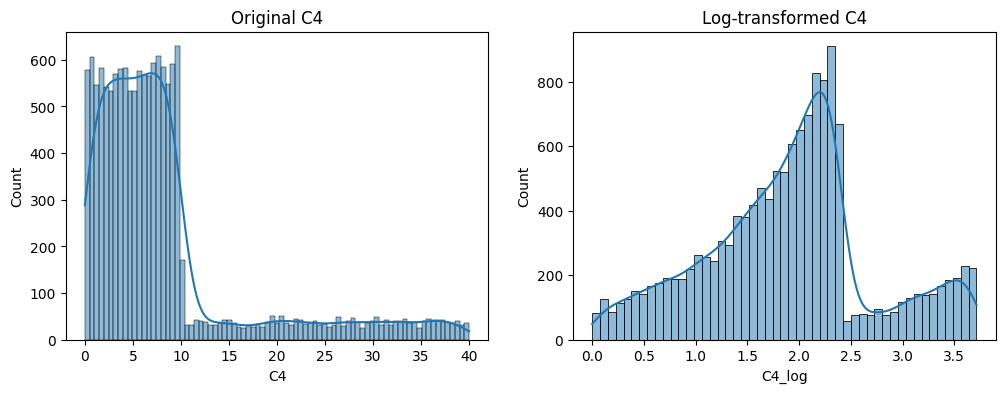

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['C4'], kde=True, ax=axes[0])
axes[0].set_title('Original C4')

sns.histplot(df['C4_log'], kde=True, ax=axes[1])
axes[1].set_title('Log-transformed C4')


In [29]:
print("Skew (before):", df['C4'].skew())
print("Skew (after):", df['C4_log'].skew())

Skew (before): 2.018484149968263
Skew (after): 0.06854114057704809


In [30]:
df.drop(columns=['C4'], inplace=True)

In [31]:
df.rename(columns={'C4_log': 'C4'}, inplace=True)

## Correlation

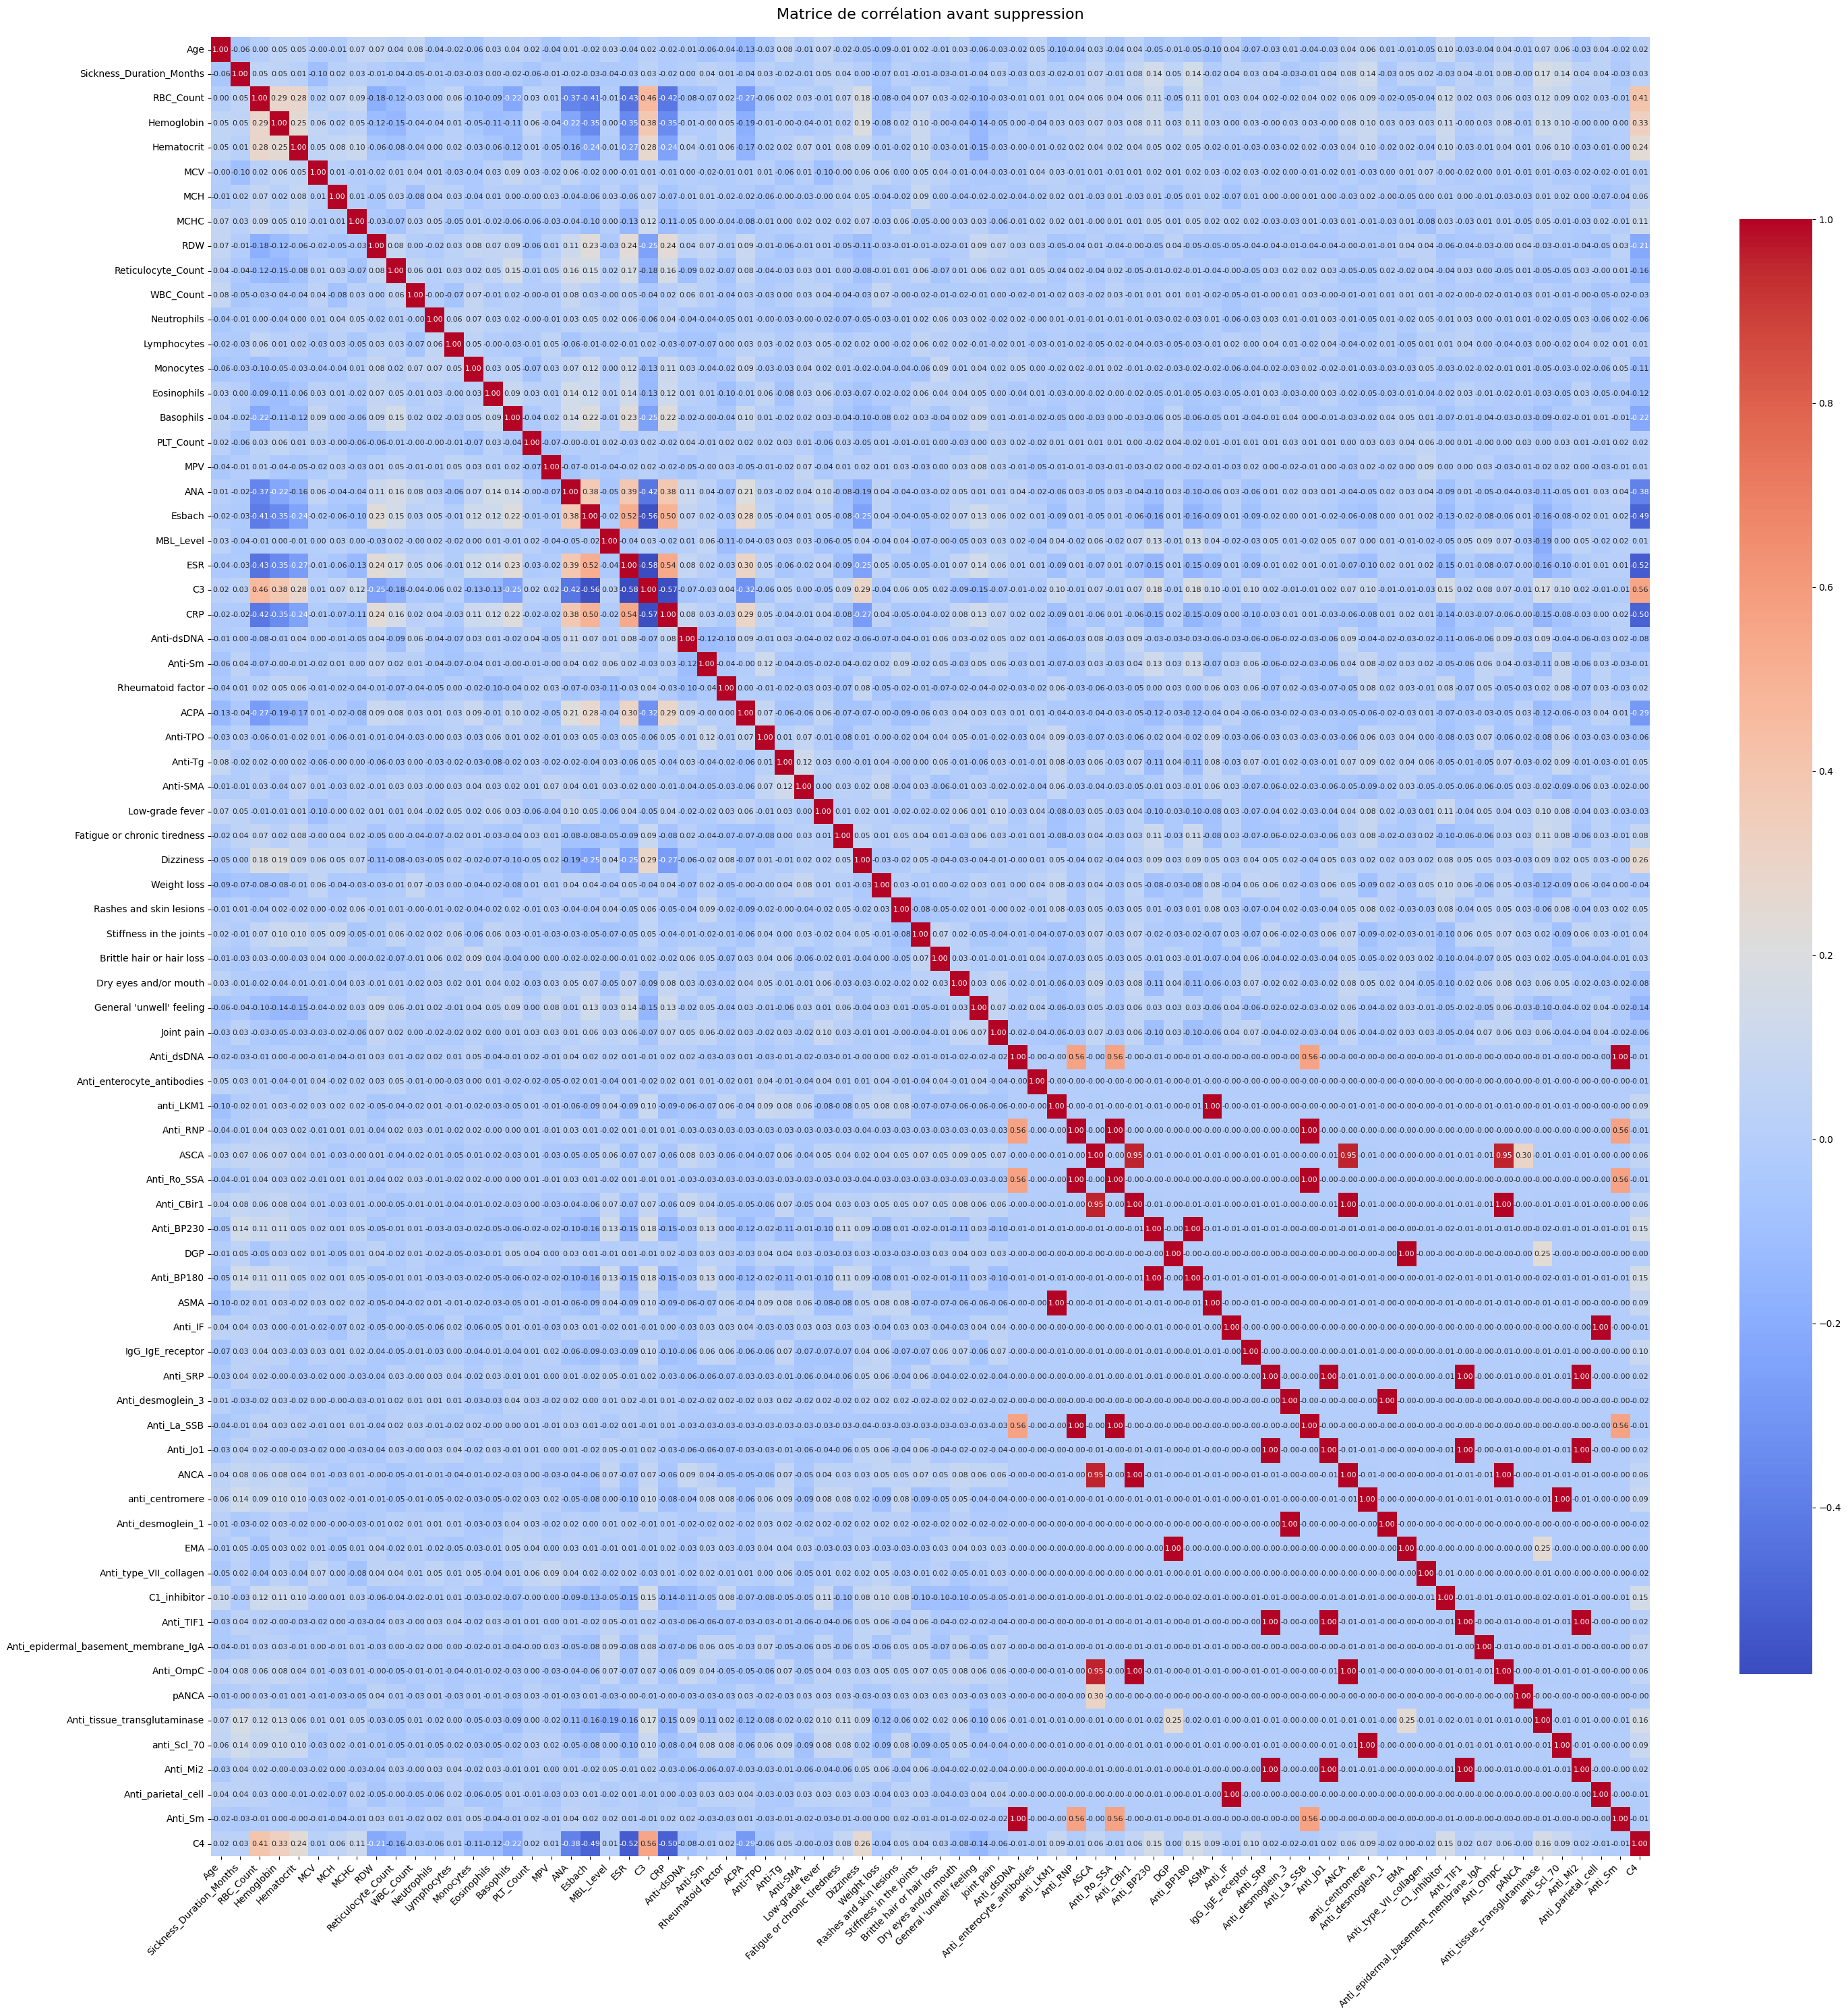

In [32]:
df_numeric = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = df_numeric.corr()

plt.figure(figsize=(30, 30))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', 
            annot_kws={'size': 8}, cbar_kws={'shrink': 0.8})
plt.title('Matrice de corrélation avant suppression', pad=20, fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

In [33]:
# Identification of high correlated features
threshold = 0.85
corr_matrix = df.corr(numeric_only=True).abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
df.drop(columns=to_drop, inplace=True)
print("Dropped ", len(to_drop) , " highly correlated features : ", to_drop)

Dropped  15  highly correlated features :  ['Anti_Ro_SSA', 'Anti_CBir1', 'Anti_BP180', 'ASMA', 'Anti_La_SSB', 'Anti_Jo1', 'ANCA', 'Anti_desmoglein_1', 'EMA', 'Anti_TIF1', 'Anti_OmpC', 'anti_Scl_70', 'Anti_Mi2', 'Anti_parietal_cell', 'Anti_Sm']


In [34]:
df.shape

(13812, 61)

## Features extraction

In [35]:
Clinical_Symptoms = [
    'Low-grade fever', 'Fatigue or chronic tiredness', 'Dizziness', 'Weight loss', 'Rashes and skin lesions',
    'Stiffness in the joints', 'Brittle hair or hair loss', 'Dry eyes and/or mouth', 'General \'unwell\' feeling',
    'Joint pain', 
]

In [36]:
df['Clinical_Symptoms_Count'] = df[Clinical_Symptoms].sum(axis=1)

# EDA 

In [37]:
# binary_cols / num_cols
categorical_columns = ['Gender', 'Diagnosis']

## Univariate Analysis

### Percentage of Gender / Diagnosis

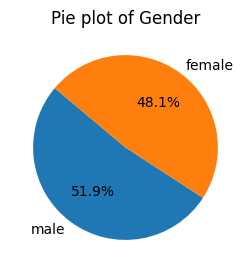

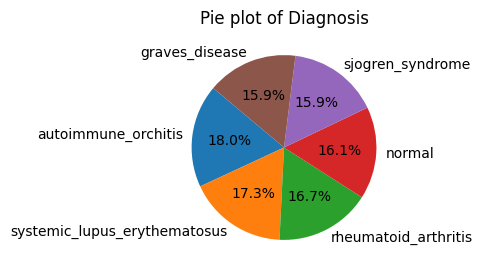

In [38]:
for col in categorical_columns:
    col_count = df[col].value_counts()
    plt.figure(figsize=(6, 3))
    plt.pie(col_count, labels=col_count.index, autopct='%1.1f%%', startangle=140)
    plt.title(f'Pie plot of {col}')
    plt.xticks(rotation=45, ha='right')
    plt.show()


## Bivariate Analysis

### Distribution of Gender by Diagnosis

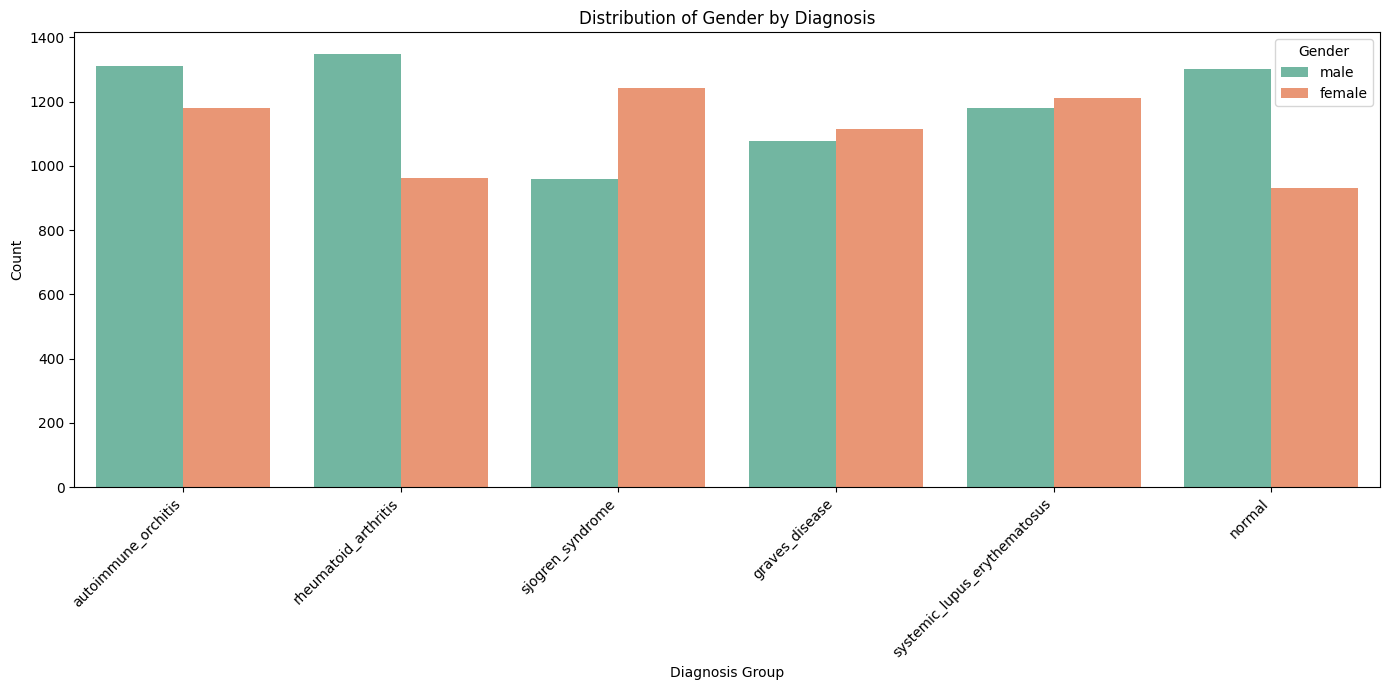

In [39]:
plt.figure(figsize=(14, 7))
sns.countplot(data=df, x='Diagnosis', hue='Gender', palette='Set2')

plt.title('Distribution of Gender by Diagnosis')
plt.xlabel('Diagnosis Group')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

# Encoding Categorical Variables

## Encoding 'Gender'

In [40]:
gender_encoder = LabelEncoder()
df['Gender'] = gender_encoder.fit_transform(df['Gender']) 

gender_map = dict(enumerate(gender_encoder.classes_))

with open('../encoder/gender.json', 'w') as f:
    json.dump(gender_map, f)


print("\nGender Mapping:")
for label, code in gender_map.items():
    print(f"{label}: {code}")



Gender Mapping:
0: female
1: male


## Encoding 'Diagnosis'

In [41]:
diagnosis_encoder = LabelEncoder()
df['Diagnosis'] = diagnosis_encoder.fit_transform(df['Diagnosis'])
diagnosis_map = dict(enumerate(diagnosis_encoder.classes_))

with open('../encoder/diagnosis.json', 'w') as f:
    json.dump(diagnosis_map, f)

print("Diagnosis Mapping:")
for label, code in diagnosis_map.items():
    print(f"{label}: {code}")

Diagnosis Mapping:
0: autoimmune_orchitis
1: graves_disease
2: normal
3: rheumatoid_arthritis
4: sjogren_syndrome
5: systemic_lupus_erythematosus


# Cleaned Dataset

In [42]:
df.to_csv("../../data/CleanedDataset.csv", index=False)
print("Cleaned dataset saved successfully !!!!")

Cleaned dataset saved successfully !!!!
